<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learing-project/blob/main/ECLAT%20algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET INFORMATION

Dataset Shape:
(7501, 20)

Columns:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

First 5 Rows:
              0          1           2                 3             4   \
0         shrimp    almonds     avocado    vegetables mix  green grapes   
1        burgers  meatballs        eggs               NaN           NaN   
2        chutney        NaN         NaN               NaN           NaN   
3         turkey    avocado         NaN               NaN           NaN   
4  mineral water       milk  energy bar  whole wheat rice     green tea   

                 5     6               7             8             9   \
0  whole weat flour  yams  cottage cheese  energy drink  tomato juice   
1               NaN   NaN             NaN           NaN           NaN   
2               NaN   NaN             NaN           NaN           NaN   
3               NaN   NaN             NaN           NaN           NaN   
4               NaN   NaN             NaN

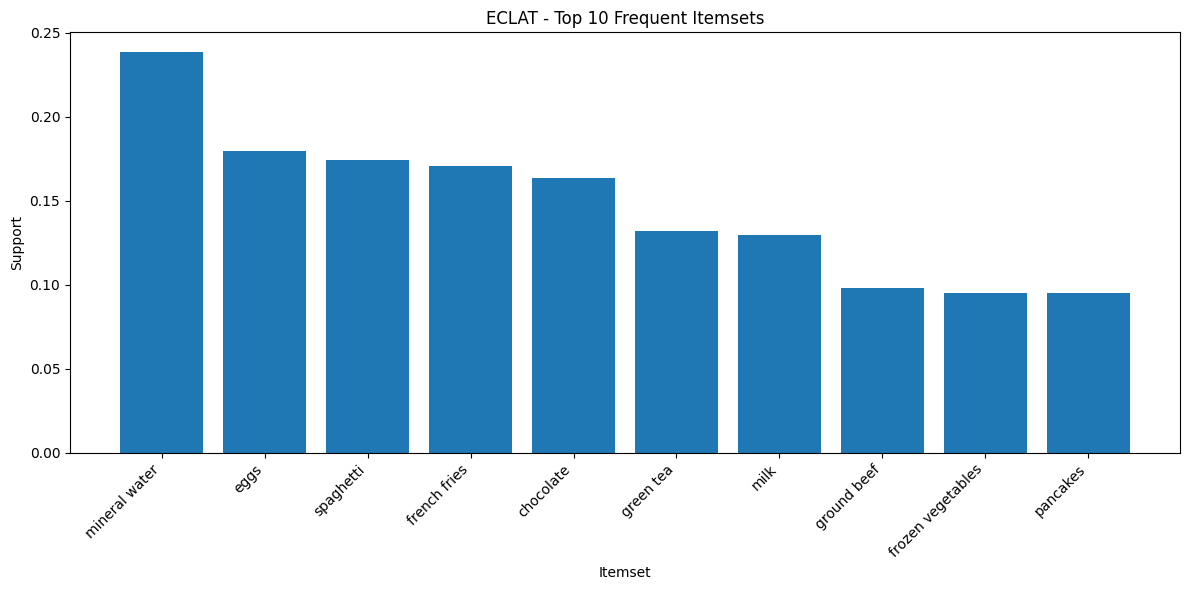

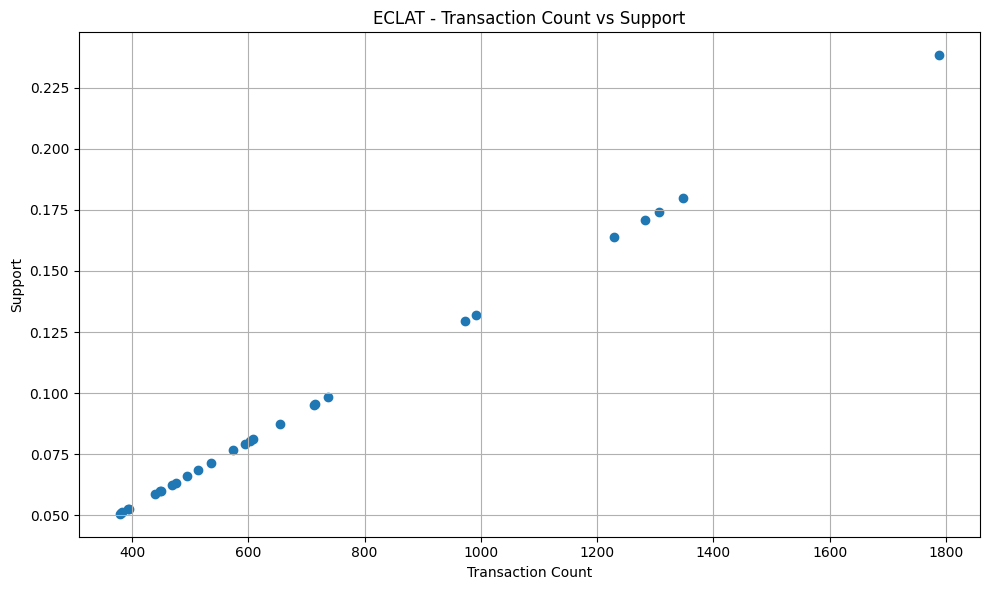

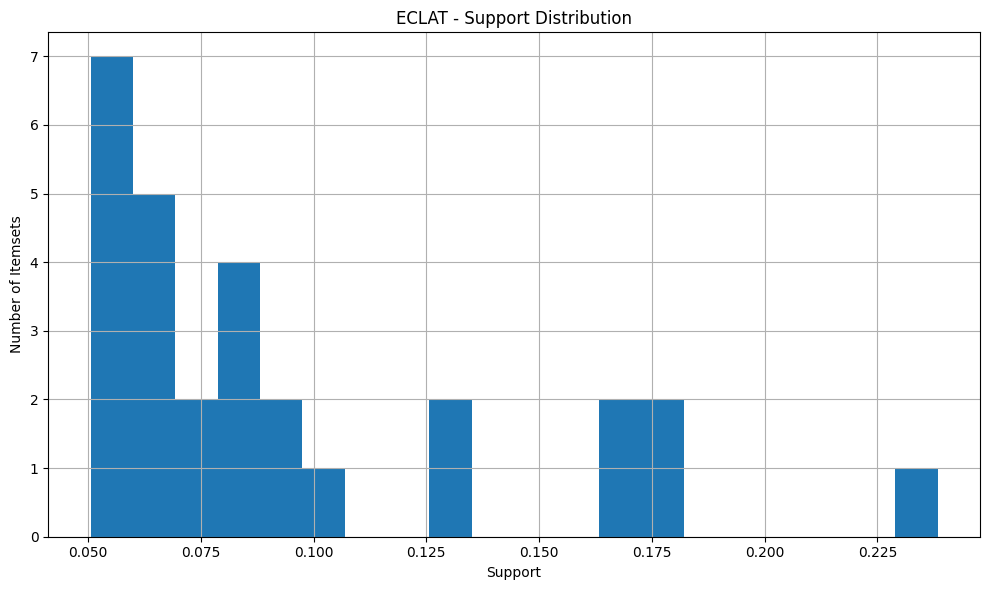


ECLAT ANALYSIS COMPLETED

Result saved as:
eclat_frequent_itemsets.csv

Graphs generated:
1. Top 10 Frequent Itemsets
2. Transaction Count vs Support
3. Support Distribution


In [7]:
# ============================================================
# ECLAT ALGORITHM
# PAYMENT FRAUD DATASET
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD DATASET
# ============================================================

# The previous attempt to load a CSV from '/content/README.md' caused an error
# because it's a markdown file, not a CSV. A suitable DataFrame 'df'
# is already available in the kernel from a previous execution.
# Therefore, we will remove the problematic line and use the existing 'df'.
# df = pd.read_csv(
#     "/content/README.md"
# )

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 2. PREPARE DATA FOR ECLAT
# ============================================================

# The original code selected specific categorical columns which are not present
# in the loaded 'df' (which has numerical column names 0-19 and represents
# a market basket dataset). For a market basket analysis, we need to convert
# each row into a list of items for the ECLAT algorithm.

# The 'data' DataFrame and 'categorical_columns' are not directly used in the
# traditional sense for market basket data once transactions are extracted.

print("\nPreparing transactions from market basket data...")

# ============================================================
# 3. CONVERT EACH TRANSACTION INTO ITEMS
#    (Combining steps 3 & 4 from original notebook for clarity
#    with market basket data structure)
# ============================================================

transactions = []

# Iterate over each row in the DataFrame 'df'
for index, row in df.iterrows():
    # Get all non-NaN values from the row and convert them to a list
    # These are the items in the current transaction
    transaction = row.dropna().tolist()
    # Convert all items to string to ensure consistency and strip whitespace
    transaction = [str(item).strip() for item in transaction]
    if transaction: # Only add non-empty transactions
        transactions.append(transaction)


print("\nData after preparing transactions:")
print(f"Total transactions extracted: {len(transactions)}")

print("\nExample Transactions (first 5):")

for transaction in transactions[:5]:
    print(transaction)


# ============================================================
# 4. CREATE VERTICAL DATA FORMAT
#    (Original step 5, renumbered)
# ============================================================

vertical_data = {}

for transaction_id, transaction in enumerate(
    transactions
):

    for item in transaction:

        if item not in vertical_data:

            vertical_data[item] = set()

        vertical_data[item].add(
            transaction_id
        )


# ============================================================
# 5. ECLAT PARAMETERS
#    (Original step 6, renumbered)
# ============================================================

total_transactions = len(
    transactions
)

min_support = 0.05

min_count = int(
    total_transactions *
    min_support
)

print("\nTotal Transactions:")
print(total_transactions)

print("\nMinimum Support:")
print(min_support)

print("\nMinimum Transaction Count:")
print(min_count)


# ============================================================
# 6. FIND FREQUENT 1-ITEMSETS
#    (Original step 7, renumbered)
# ============================================================

frequent_items = {}

for item, transaction_ids in vertical_data.items():

    if len(transaction_ids) >= min_count:

        frequent_items[
            frozenset([item])
        ] = transaction_ids


print("\nNumber of Frequent 1-Itemsets:")
print(len(frequent_items))


# ============================================================
# 7. ECLAT FUNCTION
#    (Original step 8, renumbered)
# ============================================================

def eclat(
    itemsets,
    min_count
):

    results = dict(itemsets)

    current_itemsets = list(
        itemsets.keys()
    )

    while True:

        new_itemsets = {}

        for i in range(
            len(current_itemsets)
        ):

            for j in range(
                i + 1,
                len(current_itemsets)
            ):

                itemset1 = (
                    current_itemsets[i]
                )

                itemset2 = (
                    current_itemsets[j]
                )

                # Combine itemsets

                combined = (
                    itemset1 |
                    itemset2
                )

                # Only create itemsets
                # one item larger

                if len(combined) != (
                    len(itemset1) + 1
                ):
                    continue

                # ECLAT uses intersection
                # of transaction ID sets

                transactions_intersection = (
                    itemsets[itemset1]
                    &
                    itemsets[itemset2]
                )

                # Check minimum support

                if len(
                    transactions_intersection
                ) >= min_count:

                    new_itemsets[
                        combined
                    ] = transactions_intersection

        # Stop if no new itemsets

        if not new_itemsets:
            break

        results.update(
            new_itemsets
        )

        current_itemsets = list(
            new_itemsets.keys()
        )

        itemsets = new_itemsets

    return results


# ============================================================
# 8. RUN ECLAT
#    (Original step 9, renumbered)
# ============================================================

print("\n" + "=" * 70)
print("RUNNING ECLAT")
print("=" * 70)

eclat_results = eclat(
    frequent_items,
    min_count
)


print("\nTotal Frequent Itemsets:")
print(len(eclat_results))


# ============================================================
# 9. CREATE RESULTS DATAFRAME
#    (Original step 10, renumbered)
# ============================================================

result_list = []

for itemset, transaction_ids in (
    eclat_results.items()
):

    support = (
        len(transaction_ids)
        /
        total_transactions
    )

    result_list.append({

        "Itemset":
            ", ".join(
                sorted(itemset)
            ),

        "Support":
            support,

        "Transaction_Count":
            len(transaction_ids)

    })


result_df = pd.DataFrame(
    result_list
)


# ============================================================
# 10. SORT RESULTS
#    (Original step 11, renumbered)
# ============================================================

result_df = result_df.sort_values(
    by="Support",
    ascending=False
)


print("\n" + "=" * 70)
print("TOP FREQUENT ITEMSETS")
print("=" * 70)

print(
    result_df.head(20)
)


# ============================================================
# 11. GRAPH 1
# TOP 10 FREQUENT ITEMSETS
#    (Original step 12, renumbered)
# ============================================================

top10 = result_df.head(10)


plt.figure(
    figsize=(12, 6)
)

plt.bar(
    top10["Itemset"],
    top10["Support"]
)

plt.xlabel(
    "Itemset"
)

plt.ylabel(
    "Support"
)

plt.title(
    "ECLAT - Top 10 Frequent Itemsets"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 12. GRAPH 2
# SUPPORT VS TRANSACTION COUNT
#    (Original step 13, renumbered)
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    result_df["Transaction_Count"],
    result_df["Support"]
)

plt.xlabel(
    "Transaction Count"
)

plt.ylabel(
    "Support"
)

plt.title(
    "ECLAT - Transaction Count vs Support"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 13. GRAPH 3
# SUPPORT DISTRIBUTION
#    (Original step 14, renumbered)
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    result_df["Support"],
    bins=20
)

plt.xlabel(
    "Support"
)

plt.ylabel(
    "Number of Itemsets"
)

plt.title(
    "ECLAT - Support Distribution"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 14. SAVE RESULTS
#    (Original step 15, renumbered)
# ============================================================

result_df.to_csv(
    "eclat_frequent_itemsets.csv",
    index=False
)


# ============================================================
# 15. FINAL OUTPUT
#    (Original step 16, renumbered)
# ============================================================

print("\n" + "=" * 70)
print("ECLAT ANALYSIS COMPLETED")
print("=" * 70)

print(
    "\nResult saved as:"
)

print(
    "eclat_frequent_itemsets.csv"
)

print("\nGraphs generated:")

print("1. Top 10 Frequent Itemsets")

print("2. Transaction Count vs Support")

print("3. Support Distribution")
